# Fan-in

## Static Fan-in

2026-08-13 02:09:20.465 | INFO     | __main__:node_a:16 - cur_step: 1, node_a 被触发
2026-08-13 02:09:20.466 | INFO     | __main__:node_b:22 - cur_step: 2, node_b 被触发
2026-08-13 02:09:20.466 | INFO     | __main__:node_c:28 - cur_step: 2, node_c 被触发
2026-08-13 02:09:20.467 | INFO     | __main__:node_d:34 - cur_step: 3, node_d 被触发
2026-08-13 02:09:20.467 | INFO     | __main__:node_e:40 - cur_step: 4, node_e 被触发


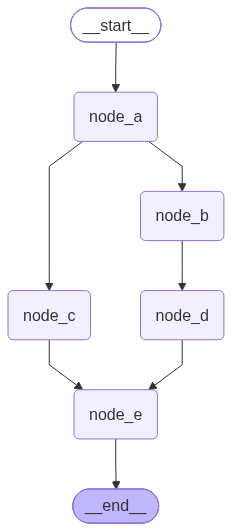

In [1]:
# demo

from typing import TypedDict

from langchain_core.runnables import RunnableConfig
from langgraph.graph import StateGraph, START
from loguru import logger


class EmptyState(TypedDict):
    pass


def node_a(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info("cur_step: {}, node_a 被触发", cur_step)
    return {}


def node_b(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info("cur_step: {}, node_b 被触发", cur_step)
    return {}


def node_c(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info("cur_step: {}, node_c 被触发", cur_step)
    return {}


def node_d(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info("cur_step: {}, node_d 被触发", cur_step)
    return {}


def node_e(state: EmptyState, config: RunnableConfig) -> EmptyState:
    cur_step = config["metadata"]["langgraph_step"]
    logger.info("cur_step: {}, node_e 被触发", cur_step)
    return {}


builder = StateGraph(state_schema=EmptyState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_node("node_d", node_d)
builder.add_node("node_e", node_e)

builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_a", "node_c")
builder.add_edge("node_b", "node_d")
builder.add_edge(["node_c", "node_d"], "node_e")

graph = builder.compile()
graph.invoke({})

from IPython.display import display

display(graph)

2026-08-13 02:11:59.374 | INFO     | __main__:node_a:16 - cur_step: 1, node_a 被触发
2026-08-13 02:11:59.376 | INFO     | __main__:node_b:22 - cur_step: 2, node_b 被触发
2026-08-13 02:11:59.377 | INFO     | __main__:node_c:28 - cur_step: 2, node_c 被触发
2026-08-13 02:11:59.379 | INFO     | __main__:node_e:40 - cur_step: 3, node_e 被触发
2026-08-13 02:11:59.380 | INFO     | __main__:node_d:34 - cur_step: 3, node_d 被触发
2026-08-13 02:11:59.383 | INFO     | __main__:node_e:40 - cur_step: 4, node_e 被触发


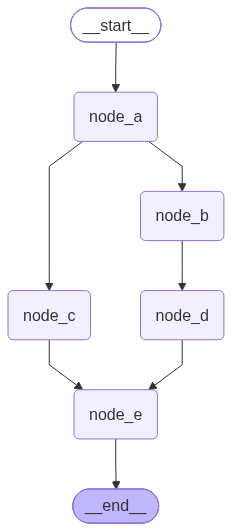

In [2]:
builder = StateGraph(state_schema=EmptyState)
builder.add_node("node_a", node_a)
builder.add_node("node_b", node_b)
builder.add_node("node_c", node_c)
builder.add_node("node_d", node_d)
builder.add_node("node_e", node_e)

builder.add_edge(START, "node_a")
builder.add_edge("node_a", "node_b")
builder.add_edge("node_a", "node_c")
builder.add_edge("node_b", "node_d")

# 独立触发：node_c 完成后可以触发 node_e
builder.add_edge("node_c", "node_e")
# 独立触发：node_d 完成后可以触发 node_e
builder.add_edge("node_d", "node_e")

graph = builder.compile()
graph.invoke({})

from IPython.display import display

display(graph)

## Dynamic Fan-in（动态扇入）

静态扇入的上游节点数量在构图时已经确定；动态扇入的 worker 数量则由**本次运行的输入**决定。图本身不需要改变，但每次调用可以创建不同数量的并行任务。

下面用词频统计实现一个 Map-Reduce 风格的动态扇入：

1. `route_documents` 读取输入文档，并为每篇文档返回一个 `Send`；文档有多少篇，就动态创建多少个 `count_words` 任务。
2. 所有 `count_words` 任务位于同一个 superstep，分别计算一篇文档的局部词频。它们可以并行执行，但不会在执行过程中直接修改彼此看到的状态。
3. 每个 worker 都写入 `partial_counts`。该字段使用 `Annotated[..., operator.add]` 注册 reducer，把并发返回的单元素列表拼接成一个列表。
4. 所有动态 worker 完成、状态更新被 reducer 合并后，`merge_word_counts` 在下一个 superstep 执行一次，将所有局部词频合并为总词频。
5. 如果输入文档为空，路由函数会直接进入聚合节点，仍然产生结构完整的空结果。

```mermaid
flowchart LR
    S([START]) --> R{route_documents}
    R -. "Send × N" .-> W["count_words × N"]
    R -->|N = 0| M[merge_word_counts]
    W --> M
    M --> E([END])
```

> 关键点：动态的是运行时创建的 `count_words` 任务数量，不是图中的节点定义数量。

In [3]:
import operator
import re
from collections import Counter
from typing import Annotated, Literal, TypedDict

from IPython.display import display
from langchain_core.runnables import RunnableConfig
from langgraph.graph import END, START, StateGraph
from langgraph.types import Send
from loguru import logger


class PartialWordCount(TypedDict):
    """一篇文档产生的局部词频。"""

    document_id: int
    counts: dict[str, int]


class WordFrequencyState(TypedDict):
    """图的共享状态。"""

    documents: list[str]
    # 多个 worker 会在同一个 superstep 并发写入该字段。
    # operator.add 将每个 worker 返回的单元素列表拼接起来；如果没有 reducer，
    # 并发写入普通字段会触发 InvalidUpdateError。
    partial_counts: Annotated[list[PartialWordCount], operator.add]
    total_counts: dict[str, int]
    processed_documents: int


class DocumentWorkerState(TypedDict):
    """通过 Send 传给单个 worker 的私有输入。"""

    document_id: int
    text: str


class PartialCountUpdate(TypedDict):
    """worker 对共享状态产生的更新。"""

    partial_counts: list[PartialWordCount]


class MergeResult(TypedDict):
    """扇入节点产生的最终统计结果。"""

    total_counts: dict[str, int]
    processed_documents: int


def route_documents(
    state: WordFrequencyState,
) -> list[Send] | Literal["merge_word_counts"]:
    """根据运行时文档数量，动态创建 0 到 N 个词频统计任务。"""

    documents = state["documents"]
    if not documents:
        # 如果直接返回空列表，图会在 START 后结束，无法生成 total_counts。
        # 因此空输入显式路由到聚合节点。
        return "merge_word_counts"

    return [
        Send(
            "count_words",
            {"document_id": document_id, "text": text},
        )
        for document_id, text in enumerate(documents)
    ]


def count_words(
    state: DocumentWorkerState,
    config: RunnableConfig,
) -> PartialCountUpdate:
    """统计一篇英文文档，并返回一个可由 reducer 拼接的单元素列表。"""

    # 本例只处理英文单词：统一转成小写，并忽略标点。
    words = re.findall(r"[a-z]+", state["text"].lower())
    counts = dict(Counter(words))

    # langgraph_step 用来观察：所有动态 worker 位于同一个 superstep。
    current_step = config["metadata"]["langgraph_step"]
    logger.info(
        "superstep={}，worker #{} 完成，共统计 {} 个单词",
        current_step,
        state["document_id"],
        len(words),
    )

    # 必须用列表包裹单篇文档的结果，才能配合 operator.add 做列表拼接。
    return {
        "partial_counts": [
            {"document_id": state["document_id"], "counts": counts}
        ]
    }


def merge_word_counts(
    state: WordFrequencyState,
    config: RunnableConfig,
) -> MergeResult:
    """等待所有 worker 后，将 reducer 收集的局部结果扇入为总词频。"""

    # 空输入会直接到达此节点，此时状态里还没有 partial_counts。
    partial_counts = state.get("partial_counts", [])
    total_counts: Counter[str] = Counter()

    for partial in partial_counts:
        total_counts.update(partial["counts"])

    # 先按频次降序、再按单词升序排列，使展示结果不依赖 worker 完成顺序。
    ordered_counts = dict(
        sorted(total_counts.items(), key=lambda item: (-item[1], item[0]))
    )

    current_step = config["metadata"]["langgraph_step"]
    logger.info(
        "superstep={}，fan-in 收到 {} 份局部结果",
        current_step,
        len(partial_counts),
    )

    return {
        "total_counts": ordered_counts,
        "processed_documents": len(partial_counts),
    }

### 构建动态扇入图

`add_conditional_edges` 接收路由函数返回的 `Send` 列表。`path_map` 列出所有可能的目标，既包括正常情况下的 worker，也包括空输入时直接到达的聚合节点。

从 `count_words` 到 `merge_word_counts` 只需要定义一条边。运行时即使创建了 N 个同名 worker 任务，LangGraph 也会先完成这一批任务并应用 reducer，然后在下一轮调度一次聚合节点。

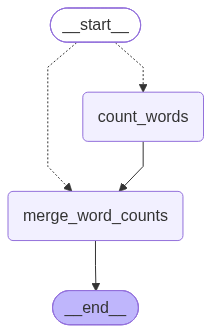

In [4]:
word_frequency_builder = StateGraph(state_schema=WordFrequencyState)
word_frequency_builder.add_node("count_words", count_words)
word_frequency_builder.add_node("merge_word_counts", merge_word_counts)

word_frequency_builder.add_conditional_edges(
    START,
    route_documents,
    path_map=["count_words", "merge_word_counts"],
)
# 这一条边代表动态 worker 集合到单个聚合节点的扇入。
word_frequency_builder.add_edge("count_words", "merge_word_counts")
word_frequency_builder.add_edge("merge_word_counts", END)

word_frequency_graph = word_frequency_builder.compile()
display(word_frequency_graph)

### 运行与验证

下面输入 4 篇短文档，因此路由函数会创建 4 个 `count_words` 任务。日志中的 worker 应处于同一个 superstep；聚合节点应在下一 superstep 收到 4 份局部结果。随后再用空列表验证零 worker 的边界情况。

In [5]:
documents = [
    "LangGraph makes fan out dynamic.",
    "Fan out creates parallel workers.",
    "Fan in waits for every worker.",
    "LangGraph fan in merges word counts.",
]

word_frequency_result = word_frequency_graph.invoke({"documents": documents})

print("局部词频：")
for partial in sorted(
    word_frequency_result["partial_counts"],
    key=lambda item: item["document_id"],
):
    print(f"  文档 {partial['document_id']}: {partial['counts']}")

print("\n合并后的总词频：")
for word, count in word_frequency_result["total_counts"].items():
    print(f"  {word:<10} -> {count}")

# 这些断言同时验证动态 worker 数量和最终扇入结果。
assert word_frequency_result["processed_documents"] == len(documents)
assert len(word_frequency_result["partial_counts"]) == len(documents)
assert word_frequency_result["total_counts"]["fan"] == 4
assert word_frequency_result["total_counts"]["langgraph"] == 2

# 边界验证：0 篇文档不会创建 worker，但仍会得到空的最终词频。
empty_result = word_frequency_graph.invoke({"documents": []})
assert empty_result["processed_documents"] == 0
assert empty_result["total_counts"] == {}
print(f"\n空输入结果：{empty_result['total_counts']}")

2026-08-13 17:16:07.331 | INFO     | __main__:count_words:84 - superstep=1，worker #0 完成，共统计 5 个单词
2026-08-13 17:16:07.337 | INFO     | __main__:count_words:84 - superstep=1，worker #1 完成，共统计 5 个单词
2026-08-13 17:16:07.338 | INFO     | __main__:count_words:84 - superstep=1，worker #2 完成，共统计 6 个单词
2026-08-13 17:16:07.338 | INFO     | __main__:count_words:84 - superstep=1，worker #3 完成，共统计 6 个单词
2026-08-13 17:16:07.346 | INFO     | __main__:merge_word_counts:118 - superstep=2，fan-in 收到 4 份局部结果
2026-08-13 17:16:07.351 | INFO     | __main__:merge_word_counts:118 - superstep=1，fan-in 收到 0 份局部结果


局部词频：
  文档 0: {'langgraph': 1, 'makes': 1, 'fan': 1, 'out': 1, 'dynamic': 1}
  文档 1: {'fan': 1, 'out': 1, 'creates': 1, 'parallel': 1, 'workers': 1}
  文档 2: {'fan': 1, 'in': 1, 'waits': 1, 'for': 1, 'every': 1, 'worker': 1}
  文档 3: {'langgraph': 1, 'fan': 1, 'in': 1, 'merges': 1, 'word': 1, 'counts': 1}

合并后的总词频：
  fan        -> 4
  in         -> 2
  langgraph  -> 2
  out        -> 2
  counts     -> 1
  creates    -> 1
  dynamic    -> 1
  every      -> 1
  for        -> 1
  makes      -> 1
  merges     -> 1
  parallel   -> 1
  waits      -> 1
  word       -> 1
  worker     -> 1
  workers    -> 1

空输入结果：{}


### 结果解读与注意事项

- 4 条 worker 日志拥有相同的 `langgraph_step`，说明它们属于同一个 superstep；这表示它们可被并行调度，不保证实际完成顺序。
- fan-in 日志位于下一个 superstep，并且只出现一次。此时 `partial_counts` 已经包含 4 份局部结果。
- `fan` 的总频次为 4，`langgraph`、`in` 和 `out` 的总频次均为 2，说明聚合节点读取到了全部 worker 更新。
- 不要让多个 worker 直接并发覆盖普通的 `total_counts` 字段；应像本例一样使用满足结合律的 reducer 收集结果，再由单个节点完成最终合并。
- 并行任务的完成顺序不应成为业务语义。本例保留 `document_id` 便于追踪，并对最终词频显式排序，保证展示稳定。
- 示例中的正则只适合英文单词。统计中文词频时，应把 `re.findall` 替换为合适的中文分词器；动态扇出和扇入结构不需要改变。

只要修改 `documents` 的长度，再次调用同一个 `word_frequency_graph`，`Send` 的数量就会随输入变化，这正是动态扇入与静态扇入的核心区别。